# 06 · Head-FT training report

What the fine-tuning did during training: checkpoint inventory and per-epoch validation learning curves, read from the fork's `val_predictions_epoch_*.csv`. This is training-time behaviour; the screening performance (EF@1% / AP on the 49,685-compound eval set) is computed separately once scoring finishes.

Note: the paper's validation set is the last 20 compounds of the ranking, which here are all inactive. So these curves show the head learning to down-weight high-ranked-but-inactive compounds (the demote-false-positives behaviour) and that training converges - not active-vs-inactive separation, which is the screening result.

In [1]:

import glob, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display
BLK="#000000"; PAL=["#2a78d6","#eb6834","#1baf7a"]
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
R="/global/scratch/users/sergiomar10/boltzaff/results/runs/588689"
rows=[]
for arm in sorted(glob.glob(R+"/headft_full/top*_seed*")):
    name=arm.split("/")[-1]
    if "work" in name: continue
    N=int(name.split("_")[0].replace("top","")); seed=int(name.split("seed")[1])
    for e in range(5):
        try: d=pd.read_csv(f"{arm}/validation_predictions/val_predictions_epoch_{e}.csv")
        except: continue
        y=d.binary_target.values; p=d.affinity_probability_binary.values
        bce=-np.mean(y*np.log(np.clip(p,1e-9,1))+(1-y)*np.log(np.clip(1-p,1e-9,1)))
        rows.append(dict(N=N,seed=seed,epoch=e,val_prob=float(p.mean()),val_bce=float(bce),n_pos=int(y.sum()),n=len(y)))
vf=pd.DataFrame(rows)
nck_main=len(glob.glob(R+"/headft_full/top*_seed*/checkpoints/last.ckpt"))
nck_var=len([p for p in glob.glob(R+"/headft_variants/*_seed*/checkpoints/last.ckpt") if "work" not in p])
print(f"checkpoints trained: main {nck_main}/15, variants {nck_var}/70")
print(f"validation set: {vf.n.iloc[0]} compounds, {vf.n_pos.iloc[0]} positive (paper protocol = last 20 of ranking)")


checkpoints trained: main 15/15, variants 70/70
validation set: 20 compounds, 0 positive (paper protocol = last 20 of ranking)


## Validation loss per epoch (mean over the 15 main arms, with seed spread)
Binary cross-entropy on the held-out validation compounds. Monotonic decrease = the fine-tune is learning and converging.

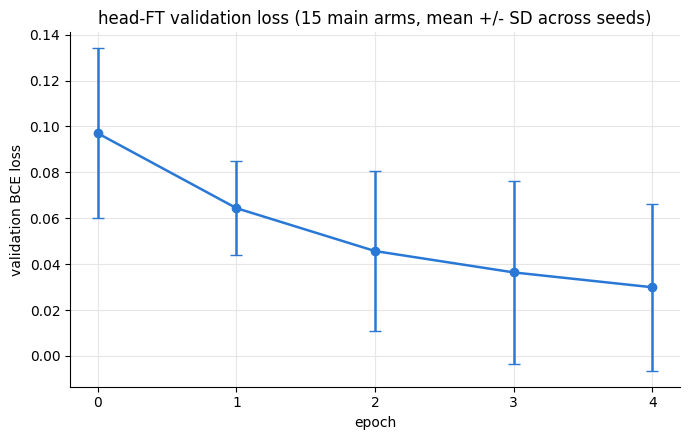

,mean,std
epoch,,
0,0.0970,0.0370
1,0.0644,0.0205
2,0.0457,0.0347
3,0.0364,0.0398
4,0.0299,0.0363


In [2]:
g=vf.groupby("epoch").val_bce.agg(["mean","std"])
fig,ax=plt.subplots(figsize=(7,4.5))
ax.errorbar(g.index,g["mean"],yerr=g["std"],marker="o",color="#2a78d6",capsize=4,lw=1.8)
ax.set_xlabel("epoch"); ax.set_ylabel("validation BCE loss"); ax.set_xticks(range(5))
ax.set_title("head-FT validation loss (15 main arms, mean +/- SD across seeds)")
plt.tight_layout(); plt.show()
display(g.round(4))

## Learning by label budget
Mean predicted probability on the (all-inactive) validation set over epochs, per budget N. Lower = the head more confidently suppresses these false positives; more labels drive stronger suppression.

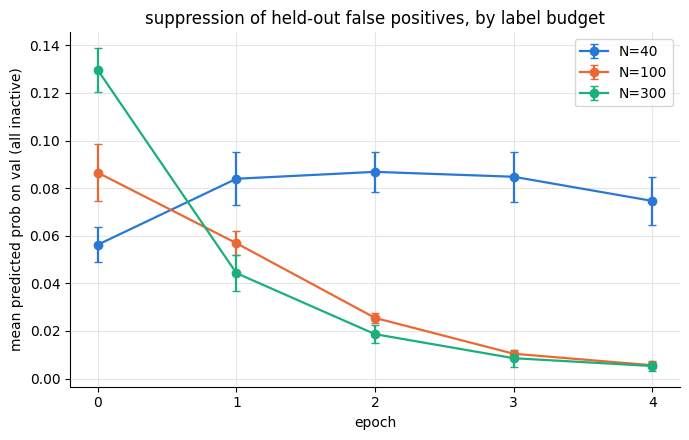

In [3]:
fig,ax=plt.subplots(figsize=(7,4.5))
for c,N in zip(PAL,[40,100,300]):
    s=vf[vf.N==N].groupby("epoch").val_prob.agg(["mean","std"])
    ax.errorbar(s.index,s["mean"],yerr=s["std"],marker="o",color=c,capsize=3,lw=1.6,label=f"N={N}")
ax.set_xlabel("epoch"); ax.set_ylabel("mean predicted prob on val (all inactive)"); ax.set_xticks(range(5))
ax.set_title("suppression of held-out false positives, by label budget"); ax.legend()
plt.tight_layout(); plt.show()

## Checkpoint inventory
Final-epoch checkpoints saved per arm (main reproduction) and the variant sweep.

In [4]:
inv=vf[vf.epoch==4].groupby("N").agg(arms=("seed","nunique"),
     final_val_bce=("val_bce","mean"), final_val_prob=("val_prob","mean")).round(4)
inv["checkpoints"]=inv.arms.astype(str)+"/5 seeds"
display(inv)
print(f"main checkpoints: {nck_main}/15   variant checkpoints: {nck_var}/70   (5 epochs each)")
print("screening performance (EF@1%/AP on 49,685 eval compounds) -> results/analysis/588689/ once scoring completes")

,arms,final_val_bce,final_val_prob,checkpoints
N,,,,
40,5,0.0789,0.0746,5/5 seeds
100,5,0.0056,0.0056,5/5 seeds
300,5,0.0053,0.0053,5/5 seeds


main checkpoints: 15/15   variant checkpoints: 70/70   (5 epochs each)
screening performance (EF@1%/AP on 49,685 eval compounds) -> results/analysis/588689/ once scoring completes
